### 1. 训练和可视化决策树

#### 1.1 决策树构建

In [4]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# 数据加载
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

# 模型训练
tree_clf = DecisionTreeClassifier(max_depth=2,random_state=42)
tree_clf.fit(X_iris,y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 1.2 决策树可视化

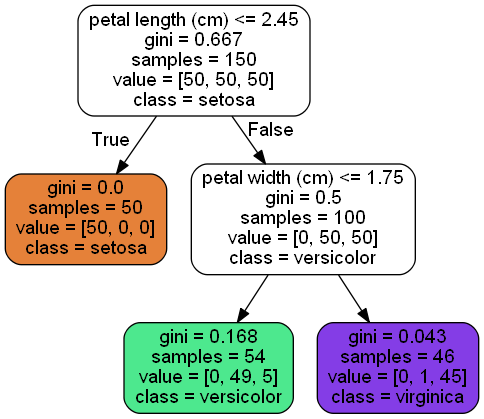

In [ ]:
# export_graphviz 的作用是将这些不可见的逻辑 “翻译” 成一种名为 DOT 的图形描述语言。
from sklearn.tree import export_graphviz
import os
from IPython.display import Image
# .dot 文件本身只是文本，需要通过 graphviz 库来将其转化为可视化的图形
export_graphviz(
    tree_clf,
    out_file="iris_tree.dot", # 输出目标,.dot 是一种文本文件，专门用来描述节点和连线关系。
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True, # 视觉优化,让图中节点的方框变成圆角
    filled=True # 逻辑可视化,非常重要！ 它会根据节点的分类倾向给节点填充颜色。颜色越深，代表该节点包含的样本纯度越高。
)

# 决策树可视化
# 1. 之前查到的 bin 目录
bin_path = r'D:\Anaconda\envs\ml_env\Library\bin'

# 2. 将 dot 命令的完整路径拼出来
dot_cmd = os.path.join(bin_path, 'dot.bat')

# 3. 手动执行命令行：将 iris_tree.dot 转换为 png 图片
# 这里的逻辑是：使用 dot 引擎，生成 png 格式，输出为 iris.png，源文件是 iris_tree.dot
os.system(f'"{dot_cmd}" -Tpng iris_tree.dot -o iris.png')
display(Image(filename="iris.png"))
